<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/266659_Proyecto_Inicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Proyecto Analisis Descriptivo de los Datos - Etapa 2: ADD
Tema: Casos COVID-19 en Mexico

Materia: Programacion para analitica descriptiva y predicitva

Docente: Dr. Vicente Garcia Jimenez

Alumno: Edgar Soto Jimenez

Matricula: 266659

Periodo: Ene - May 2026

Fecha: 3/25/26

# Introduccion

Parte 1
*   Seleccion e conjunto de datos
*   Definicion del problema
*   Problema a estudiar
*   Justificacion
*   Analisis descriptivo

Parte 2

*   Descripcion del dataset
*   Revision de la calidad de datos
*   Procesamiento de datos
*   Analisis Univariado
*   Analisis bivariado
*   Analisis Multivariado
*   Visualizaciones para responder preguntas
*   Conclusiones




# Seleccion de conjunto de datos

*  Database: Base de datos de casos COVID-19 en Mexico

*   Portal Oficial: Gobierno de mexico - Datos abiertos

*   Fuente: Direccion general de epidemiologia

*   Portal Oficial:Gobierno de mexico - Datos abiertos

*  Enlace general: https://www.gob.mx/salud/documentos/datos-abiertos-152127


**Seleccion de conjunto de datos**

Tipo de datos:
*   Variables numericas (edad, fechas e indicadores binarios)
*   Variables binarias (intubado, neumonia, defuncion, hipertension, EPOC, etc)
*   Variables categoricas (Sexo, entidad federativa, tipo de paciente)


**Seleccion de conjunto de datos**

 Contexto: La investigacion fue realizada por el dpto. del sistma de salud de Mexico donde se registraron los casos oficiales y sospechosos de COVID-19 en Mexico, con el inicio, evolucion y descenlace del paciente.

# Definicion del problema

**Contexto del analisis**

La pandemia del COVID-19 registro un impacto significativo en Mexico. Analizar los datos oficiales nos puede permitir el comportamiento demografica de la pandemia y factores de mortalidad en la comunidad.

# Problema a estudiar

Identificar las caracteristicas asociadas a presentar mayor probabilidd de hopitalizacion y defuncion (enfermedades agudas o cronicas)

# Justificacion

Un analisis descriptivo nos permite entnder los grupos de riesgo y patrones epdemiologicos que apoyan a una correcta toma de desiciones

# Analisis descriptivo

 Formulacion de preguntas



1.   ¿Que proporcion de pacientes fue hospitalizada?

2.   ¿Que es la distribucion de edad en los pacientes?

3.   ¿Que porcentaje de los casos corresponde a hombres y mujeres?

4. ¿Cual es la tasa de defuncion registrada?

5. ¿Existe relacion entre edad y la probabilidad de defuncion?

Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

Carga de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta_data = '/content/drive/MyDrive/Colab Notebooks/COVID19MEXICO.csv'
ruta_catalogo = '/content/drive/MyDrive/Colab Notebooks/240708 Catalogos.xlsx'

df = pd.read_csv(ruta_data, low_memory=False)
catalogos = pd.read_excel(ruta_catalogo, sheet_name=None)

# Normalizar columnas
df.columns = df.columns.str.upper().str.strip()

df.head()

Descripcion del dataset

In [ ]:
print("Dimensiones:", df.shape)
df.info()
df.describe()

Crear diccionarios

In [ ]:
diccionarios = {}

for nombre, tabla in catalogos.items():
    try:
        tabla = tabla.dropna()
        col_codigo = tabla.columns[0]
        col_desc = tabla.columns[1]

        dic = dict(zip(tabla[col_codigo], tabla[col_desc]))
        diccionarios[nombre.upper()] = dic

    except:
        print(f"Error en hoja: {nombre}")

Limpieza inteligente

In [ ]:
# Valores especiales del dataset
valores_invalidos = [97, 98, 99, 999]

for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].replace(valores_invalidos, np.nan)

Aplicar catalogos

In [ ]:
for col in df.columns:
    if col in diccionarios:
        df[col] = df[col].map(diccionarios[col])

Convertir categorias

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

Limpieza de edad

In [ ]:
# Filtrar edades irreales
df = df[(df['EDAD'] >= 0) & (df['EDAD'] <= 120)]

Valores faltantes

In [ ]:
df.isnull().sum()

In [ ]:
# Imputación simple
df.fillna(df.median(numeric_only=True), inplace=True)

Outliers

In [ ]:
Q1 = df['EDAD'].quantile(0.25)
Q3 = df['EDAD'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['EDAD'] < lim_inf) | (df['EDAD'] > lim_sup)]

print("Outliers en edad:", outliers.shape[0])

Visualizaciones

In [ ]:
df['EDAD'].hist(bins=30)
plt.title("Distribución de Edad")
plt.show()

Boxplot

In [ ]:
sns.boxplot(x=df['EDAD'])
plt.title("Outliers en Edad")
plt.show()

Variables categoricas

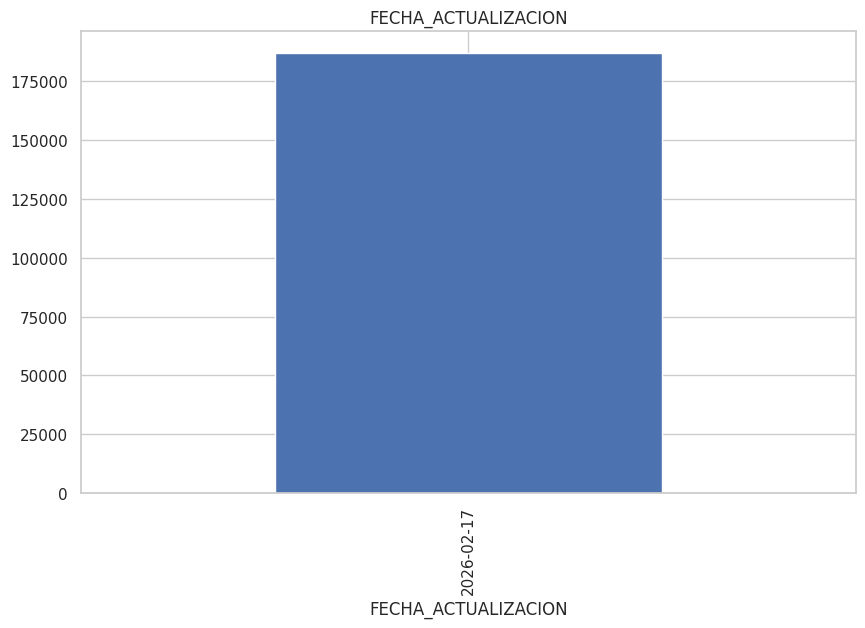

In [ ]:
for col in df.select_dtypes(include='category').columns[:5]:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

Analisis bivariado

In [ ]:
# Ejemplo: Edad vs Tipo de paciente
if 'TIPO_PACIENTE' in df.columns:
    sns.boxplot(x='TIPO_PACIENTE', y='EDAD', data=df)
    plt.xticks(rotation=45)
    plt.show()

Correlacion

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

Multivariado

In [ ]:
sns.pairplot(df.select_dtypes(include=np.number).sample(1000))
plt.show()

Seccion de respuesta a preguntas

Pregunta 1: Que proporcion de pacientes fueron hospitalizados?

In [ ]:
# Conteo
hospitalizados = df['TIPO_PACIENTE'].value_counts(normalize=True) * 100

print(hospitalizados)

# Gráfica
hospitalizados.plot(kind='bar')
plt.title("Proporción de pacientes hospitalizados")
plt.ylabel("%")
plt.show()

Se observa que

Pregunta 2. Cual es la distribucion de edad?

In [ ]:
df['EDAD'].hist(bins=30)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

Pregunta 3. Que porcentaje corresponde a Mujeres y hombres?

In [ ]:
sexo_pct = df['SEXO'].value_counts(normalize=True) * 100

print(sexo_pct)

# Gráfica
sexo_pct.plot(kind='bar')
plt.title("Distribución por sexo")
plt.ylabel("%")
plt.show()

Pregunta 4.  Cual es la tasa de defuncion?

In [ ]:
# Crear variable binaria
df['DEFUNCION'] = df['FECHA_DEF'].notna().astype(int)

# Calcular tasa
tasa_def = df['DEFUNCION'].mean() * 100

print(f"Tasa de defunción: {tasa_def:.2f}%")

# Gráfica
df['DEFUNCION'].value_counts(normalize=True).plot(kind='bar')
plt.title("Defunción vs No defunción")
plt.show()

Pregunta 5. Existe relacion entre edad y defuncion?

In [ ]:
# Crear variable binaria
df['DEFUNCION'] = df['FECHA_DEF'].notna().astype(int)

# Calcular tasa
tasa_def = df['DEFUNCION'].mean() * 100

print(f"Tasa de defunción: {tasa_def:.2f}%")

# Gráfica
df['DEFUNCION'].value_counts(normalize=True).plot(kind='bar')
plt.title("Defunción vs No defunción")
plt.show()

Promedio de edad de grupo

In [ ]:
df.groupby('DEFUNCION')['EDAD'].mean()

Probabilidad por rangos de edad

In [ ]:
# Crear grupos de edad
df['GRUPO_EDAD'] = pd.cut(df['EDAD'], bins=[0,20,40,60,80,120])

# Calcular tasa de defunción por grupo
tasa_por_edad = df.groupby('GRUPO_EDAD')['DEFUNCION'].mean() * 100

print(tasa_por_edad)

# Gráfica
tasa_por_edad.plot(kind='bar')
plt.title("Probabilidad de defunción por grupo de edad")
plt.ylabel("%")
plt.show()